# LENDING CLUB

# MODELAGEM DA PROBABILIDADE DE DEFAULT

# 1. IMPORTANDO BIBLIOTECAS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelagem
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, roc_curve

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

import warnings
warnings.filterwarnings('ignore')

# 2. CONJUNTO DE DADOS

In [2]:
# Carrega o dataframe pré-processado (saída do notebook 01)
df = pd.read_parquet('dados/loan_data_preprocessado.parquet')
print(f'Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}')
df.head()

Linhas: 241,712 | Colunas: 35


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,mths_since_earliest_cr_line,default,mths_since_last_delinq_missing,tot_coll_amt_missing,tot_cur_bal_missing,total_rev_hi_lim_missing
94,4000,4000,36,7.4300,124.3100,A,A2,0,RENT,40000.0000,Not Verified,2007-08-01,educational,NJ,3.4500,0.0000,0.0000,0.0000,2.0000,0.0000,330,11.0000,4.0000,f,0.0000,0.0000,0.0000,0.0000,0.0000,181,1,0,1,1,1
96,2000,2000,36,8.7000,63.3200,B,B1,0,RENT,70000.0000,Not Verified,2007-08-01,credit_card,NY,6.0700,0.0000,1.0000,24.0000,13.0000,0.0000,5967,19.8000,17.0000,f,0.0000,0.0000,0.0000,0.0000,0.0000,208,1,0,1,1,1
109,4000,4000,36,10.9100,130.7900,C,C3,1,RENT,18000.0000,Not Verified,2007-08-01,car,VA,18.0000,0.0000,1.0000,0.0000,4.0000,0.0000,5533,79.6000,5.0000,f,0.0000,0.0000,0.0000,0.0000,0.0000,196,1,0,1,1,1
110,15000,15000,36,12.1700,499.4500,D,D2,1,MORTGAGE,83200.0000,Not Verified,2007-08-01,credit_card,WI,17.0200,0.0000,5.0000,73.0000,14.0000,0.0000,37570,59.5000,37.0000,f,0.0000,0.0000,0.0000,0.0000,0.0000,266,1,0,1,1,1
111,3000,3000,36,7.7500,93.6700,A,A3,9,OWN,50000.0000,Not Verified,2007-08-01,vacation,WA,5.3500,0.0000,0.0000,0.0000,17.0000,0.0000,21050,0.7000,29.0000,f,0.0000,0.0000,0.0000,0.0000,0.0000,399,1,0,1,1,1


# 3. DIVISÃO TREINO-TESTE (OUT-OF-TIME)

Em problemas de crédito, a divisão entre treino e teste é feita de forma temporal (*out-of-time*), e não aleatória. O modelo é treinado com os empréstimos mais antigos e avaliado nos mais recentes, reproduzindo a situação real de uso: prever o comportamento de tomadores futuros a partir de dados do passado. Como os dados já estão ordenados cronologicamente por `issue_d`, utilizamos os primeiros 80% das observações para treino e os 20% finais para teste.

In [3]:
# Divisão out-of-time: 80% mais antigos para treino, 20% mais recentes para teste
# (o dataframe já está ordenado por issue_d, feito no notebook 01)
ponto_corte = int(len(df) * 0.80)

train = df.iloc[:ponto_corte].copy()
test = df.iloc[ponto_corte:].copy()

print(f'Treino: {train.shape[0]:,} linhas | {train["issue_d"].min().date()} a {train["issue_d"].max().date()}')
print(f'Teste:  {test.shape[0]:,} linhas | {test["issue_d"].min().date()} a {test["issue_d"].max().date()}')

Treino: 193,369 linhas | 2007-08-01 a 2014-05-01
Teste:  48,343 linhas | 2014-05-01 a 2014-12-01


In [4]:
# Distribuição do alvo em treino e teste (1 = adimplente, 0 = inadimplente)
dist_train = train['default'].value_counts(normalize=True).sort_index() * 100
dist_test = test['default'].value_counts(normalize=True).sort_index() * 100

comparacao = pd.DataFrame({
    'treino (%)': dist_train.round(2),
    'teste (%)': dist_test.round(2)
})
comparacao.index = ['Inadimplente (0)', 'Adimplente (1)']
print(comparacao)
print()
print(f'Taxa de default no treino: {(train["default"]==0).mean()*100:.2f}%')
print(f'Taxa de default no teste:  {(test["default"]==0).mean()*100:.2f}%')

                  treino (%)  teste (%)
Inadimplente (0)     19.8800    25.7500
Adimplente (1)       80.1200    74.2500

Taxa de default no treino: 19.88%
Taxa de default no teste:  25.75%


In [5]:
# Taxa de default por mês de emissão (issue_d)
default_mensal = (
    df.groupby('issue_d')
    .agg(total=('default', 'size'),
         inadimplentes=('default', lambda x: (x == 0).sum()))
)
default_mensal['taxa_default'] = default_mensal['inadimplentes'] / default_mensal['total'] * 100

# Data da fronteira treino/teste
data_corte = train['issue_d'].max()
print(f'Fronteira treino/teste: {data_corte.date()}')
default_mensal.tail(15)

Fronteira treino/teste: 2014-05-01


,total,inadimplentes,taxa_default
issue_d,,,
2013-10-01,7006,1610,22.9803
2013-11-01,7040,1617,22.9688
2013-12-01,7050,1548,21.9574
2014-01-01,6969,1604,23.0162
2014-02-01,6269,1550,24.7248
2014-03-01,6686,1628,24.3494
2014-04-01,7350,1853,25.2109
2014-05-01,7045,1775,25.1952
2014-06-01,6015,1535,25.5195


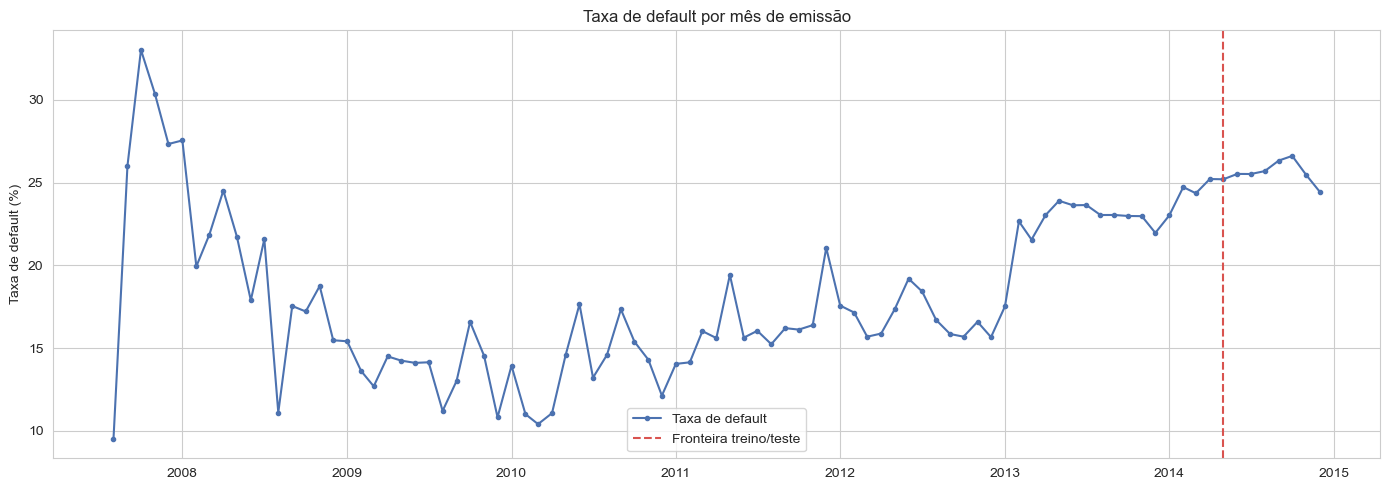

In [6]:
# Gráfico: taxa de default mensal com a fronteira treino/teste
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(default_mensal.index, default_mensal['taxa_default'],
        marker='o', markersize=3, color='#4c72b0', label='Taxa de default')
ax.axvline(data_corte, color='#d9534f', linestyle='--', label='Fronteira treino/teste')

ax.set_title('Taxa de default por mês de emissão')
ax.set_xlabel('')
ax.set_ylabel('Taxa de default (%)')
ax.legend()
plt.tight_layout()
plt.show()

### Investigação da diferença de inadimplência entre treino e teste

A divisão out-of-time resultou em taxas de inadimplência distintas entre treino (19,88%) e teste (25,75%). Para compreender essa diferença, analisamos a taxa de default por mês de emissão ao longo de toda a série.

O gráfico revela três fases: um período inicial (2007-2008) com taxas altas e voláteis, característico do início da operação; um período intermediário estável (2009-2012), com inadimplência entre 11% e 18%; e uma elevação consistente a partir de 2013, atingindo o patamar de 24-26%, no qual se situa integralmente o conjunto de teste.

Essa elevação decorre de dois fatores. Primeiro, um efeito de maturação da carteira: como a base termina em 2014, os empréstimos originados nesse período só puderam registrar os defaults ocorridos precocemente, enquanto os contratos que seriam quitados ao longo de 36 a 60 meses ainda estariam em andamento (`Current`) e foram removidos no pré-processamento. Isso concentra defaults precoces no final da série. Segundo, uma possível flexibilização das condições de concessão no período de expansão do Lending Club.

A diferença é, portanto, uma característica real dos dados, e não um artefato do particionamento. Ela não compromete a validade do modelo, uma vez que as métricas de ordenação (KS e AUC) avaliam a capacidade de distinguir bons e maus pagadores, robusta a variações na taxa base. A diferença será considerada na análise da calibração e na interpretação dos resultados.

# 4. WEIGHT OF EVIDENCE (WoE) E INFORMATION VALUE (IV)

Antes de estimar o modelo, as variáveis são transformadas pela técnica de *Weight of Evidence* (WoE), amplamente utilizada na construção de *scorecards* de crédito. A ideia central é discretizar cada variável em faixas (categorias) e substituir cada faixa por um valor que expressa o quanto ela separa bons de maus pagadores.

## Weight of Evidence (WoE)

Para cada faixa de uma variável, o WoE é definido como:

$$WoE = \ln\left(\frac{\text{proporção de bons pagadores na faixa}}{\text{proporção de maus pagadores na faixa}}\right)$$

Onde a "proporção de bons" é o número de bons pagadores da faixa dividido pelo total de bons pagadores, e analogamente para os maus. A interpretação é direta:

- **WoE positivo**: a faixa concentra proporcionalmente mais bons pagadores que maus (menor risco).
- **WoE negativo**: a faixa concentra proporcionalmente mais maus pagadores (maior risco).
- **WoE próximo de zero**: a faixa não discrimina risco.

A transformação WoE traz vantagens para a regressão logística: lida naturalmente com variáveis categóricas e com valores ausentes (que se tornam uma faixa própria), acomoda relações não lineares entre a variável e o risco, e coloca todas as variáveis em uma escala comparável.

## Information Value (IV)

Enquanto o WoE mede o poder discriminatório de cada *faixa*, o *Information Value* (IV) resume o poder preditivo da *variável inteira* em um único número:

$$IV = \sum_{\text{faixas}} (\text{prop. de bons} - \text{prop. de maus}) \times WoE$$

O IV é usado para selecionar variáveis. Uma referência usual de interpretação é:

| IV | Poder preditivo |
|---|---|
| < 0,02 | Sem poder preditivo |
| 0,02 – 0,10 | Fraco |
| 0,10 – 0,30 | Médio |
| 0,30 – 0,50 | Forte |
| > 0,50 | Muito forte (verificar sobreajuste) |

Variáveis com IV muito baixo são descartadas por não contribuírem para o modelo; variáveis com IV muito alto devem ser

Para ilustrar o cálculo, aplicamos a técnica a uma variável categórica (`grade`), que não requer discretização prévia. Os valores são calculados **apenas sobre o conjunto de treino**, evitando vazamento de informação do teste.

In [7]:
def calcular_woe_iv(dados, feature, alvo='default'):
    """
    Calcula WoE por faixa e IV total de uma variável.
    Convenção: alvo=1 (bom/adimplente), alvo=0 (mau/inadimplente).
    WoE = ln(prop_bons / prop_maus).
    """
    g = dados.groupby(feature, observed=True)[alvo].agg(['count', 'sum'])
    g.columns = ['total', 'bons']
    g['maus'] = g['total'] - g['bons']
    g['prop_bons'] = g['bons'] / g['bons'].sum()
    g['prop_maus'] = g['maus'] / g['maus'].sum()
    g['woe'] = np.log(g['prop_bons'] / g['prop_maus'])
    g['iv_faixa'] = (g['prop_bons'] - g['prop_maus']) * g['woe']
    g['taxa_default_%'] = g['maus'] / g['total'] * 100
    iv = g['iv_faixa'].sum()
    return g.round(4), round(iv, 4)

# Exemplo: grade (categórica, calculada só no treino)
tabela_grade, iv_grade = calcular_woe_iv(train, 'grade')
print(tabela_grade[['total', 'bons', 'maus', 'taxa_default_%', 'woe', 'iv_faixa']])
print(f'\nIV de grade: {iv_grade}')

       total   bons   maus  taxa_default_%     woe  iv_faixa
grade                                                       
A      33503  31112   2391          7.1367  1.1720    0.1625
B      61687  52705   8982         14.5606  0.3757    0.0400
C      48257  37370  10887         22.5605 -0.1605    0.0067
D      29671  21140   8531         28.7520 -0.4864    0.0416
E      13210   8482   4728         35.7911 -0.8094    0.0552
F       5620   3297   2323         41.3345 -1.0437    0.0409
G       1421    822    599         42.1534 -1.0774    0.0111

IV de grade: 0.358


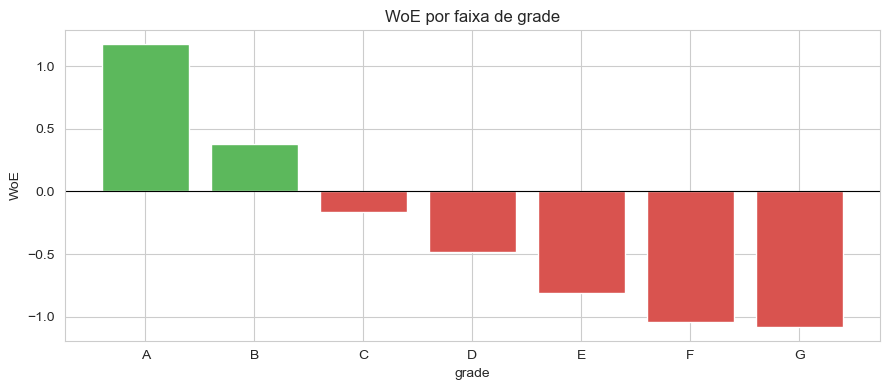

In [8]:
# Visualização do WoE por faixa de grade
plt.figure(figsize=(9, 4))
plt.bar(tabela_grade.index.astype(str), tabela_grade['woe'],
        color=['#5cb85c' if w > 0 else '#d9534f' for w in tabela_grade['woe']])
plt.axhline(0, color='black', linewidth=0.8)
plt.title('WoE por faixa de grade')
plt.xlabel('grade')
plt.ylabel('WoE')
plt.tight_layout()
plt.show()

O `grade` apresenta WoE perfeitamente monotônico: decresce de +1,17 (grade A) a -1,08 (grade G), acompanhando o aumento da taxa de inadimplência (de 7% a 42%). Com IV de 0,358, é uma variável de forte poder preditivo. Esse comportamento confirma que a classificação de risco do Lending Club ordena adequadamente os tomadores.

# 5. SELEÇÃO DE VARIÁVEIS POR INFORMATION VALUE

Antes de discretizar as variáveis com detalhe, calculamos o Information Value (IV) de cada candidata para identificar as mais preditivas. Esse passo evita investir esforço em variáveis sem poder discriminatório. A variável `addr_state` (estado do tomador) foi excluída por decisão metodológica: o uso da localização geográfica na concessão de crédito pode introduzir viés discriminatório contra determinadas regiões, o que é indesejável em um modelo responsável.

In [10]:
# Variáveis candidatas (addr_state excluída por risco de viés geográfico)
alvo = 'default'
excluir = [alvo, 'issue_d', 'addr_state']

categoricas = [c for c in train.select_dtypes(include=['object', 'category', 'string']).columns
               if c not in excluir]
numericas = [c for c in train.select_dtypes(include=[np.number]).columns
             if c not in excluir]

# IV de cada variável (numéricas discretizadas por decis, categóricas diretas)
resultados = []
tmp = train.copy()
for col in numericas:
    try:
        tmp['_bin'] = pd.qcut(train[col], q=10, duplicates='drop')
        _, iv = calcular_woe_iv(tmp, '_bin')
    except Exception:
        iv = np.nan
    resultados.append(('numérica', col, iv))
for col in categoricas:
    _, iv = calcular_woe_iv(train, col)
    resultados.append(('categórica', col, iv))

tabela_iv = (pd.DataFrame(resultados, columns=['tipo', 'variavel', 'IV'])
             .sort_values('IV', ascending=False)
             .reset_index(drop=True))
tabela_iv

,tipo,variavel,IV
0,categórica,sub_grade,0.3884
1,categórica,int_rate_bin,0.3805
2,numérica,int_rate,0.3805
3,categórica,grade,0.3580
4,numérica,dti,0.0704
5,numérica,revol_util,0.0596
6,numérica,annual_inc,0.0482
7,numérica,tot_cur_bal,0.0425
8,categórica,verification_status,0.0363
9,numérica,funded_amnt,0.0324
